In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'torch', 'torchvision']
imports = {'pillow': 'PIL'}
pinned = {}
fallbacks = {'torch': 'torch==2.11.0', 'torchvision': 'torchvision==0.26.0'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "591ab4e3a3e575d95d805a92550ef076fd65a824"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/591ab4e3a3e575d95d805a92550ef076fd65a824/d2l"
for name in ('__init__.py', 'torch.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Noise-Conditional Score Networks and Annealed Langevin Dynamics

The previous section ended with a trade-off that no single noise level can
resolve: a heavily smoothed distribution lets Langevin dynamics mix and its
score be learned wherever the noisy data reach, but its samples are blurred; a lightly smoothed
one preserves the data but restores slow mixing and unreliable scores.
@song2019generative resolve the trade-off by using many noise
levels at once. A single network, conditioned on the noise level, learns the
score of the perturbed data at every level of a ladder from coarse to fine.
Sampling then anneals: it runs Langevin dynamics at the coarsest level,
where the chain moves freely, and hands the result to the next level as its
starting point, ending at a level so fine that the perturbed distribution is
practically the data distribution. This section builds the network and the
sampler, verifies on the running example that annealing recovers what a
single level could not, and applies the noise-conditional network to images.
The presentation follows lecture 12 of @Kuleshov.2023 .

In [1]:
%matplotlib inline
from d2l import torch as d2l
import math
import torch
from torch import nn

## A Ladder of Noise Levels

Fix a decreasing sequence of noise levels
$\sigma_1 > \sigma_2 > \cdots > \sigma_L > 0$. The largest is chosen so that
$p_{\sigma_1}$ is close to a single broad Gaussian, with no valleys left
between the modes of the data (@Song.Ermon.2020 make this precise
by taking $\sigma_1$ about as large as the largest distance between two
training points); the smallest is chosen so small that
$p_{\sigma_L}$ is indistinguishable from the data for practical purposes.
The levels in between are spaced geometrically, so that each perturbed
density differs from its neighbors by a fixed ratio of noise scales.
the figure shows what the ladder does to the
running example: at $\sigma = 2$ the three modes have merged into one bump,
at $\sigma = 1$ they are connected through regions of appreciable density,
and at $\sigma = 0.5$ they are nearly separate again.

![The running example under increasing Gaussian perturbation. Crosses mark the component means. As the noise level grows, the valleys between the modes fill in, until at $\sigma = 2$ a single broad bump remains whose score points inward from everywhere.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-diffusion-noise-ladder.svg)

### One Network for All Levels

Each level has its own score, so a separate network per level would be one
option. A better one is a single network that takes the noise level as an
additional input, a **noise-conditional score network**
$\mathbf{s}_{\boldsymbol{\theta}}(\mathbf{x}, \sigma)$, trained on the
denoising objective of that section at all levels
simultaneously:

$$
\mathcal{L}(\boldsymbol{\theta})
= \frac{1}{L} \sum_{i=1}^{L} \lambda(\sigma_i)\;
\mathbb{E}_{\mathbf{x} \sim p,\ \boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, I)}
\left[\, \frac{1}{2} \Big\| \mathbf{s}_{\boldsymbol{\theta}}(\mathbf{x} + \sigma_i \boldsymbol{\epsilon}, \sigma_i) + \frac{\boldsymbol{\epsilon}}{\sigma_i} \Big\|^2 \right].
$$

A single network also keeps the number of parameters independent of the
number of levels, which matters for images: @Song.Ermon.2020 use
ladders with hundreds of levels. The weights $\lambda(\sigma_i)$ balance
the levels. The regression target $-\boldsymbol{\epsilon} / \sigma_i$ has
squared norm of order $d / \sigma_i^2$, so without weighting the finest
levels would dominate the loss by orders of magnitude.
@song2019generative choose $\lambda(\sigma) = \sigma^2$, which turns
each level's term into
$\tfrac12 \mathbb{E}\|\sigma_i \mathbf{s}_{\boldsymbol{\theta}} + \boldsymbol{\epsilon}\|^2$,
a regression onto a target of unit variance per coordinate, so that the
levels contribute terms of the same order of magnitude instead of being
dominated by the finest ones. The same choice suggests the parameterization
$\mathbf{s}_{\boldsymbol{\theta}}(\mathbf{x}, \sigma) =
\mathbf{f}_{\boldsymbol{\theta}}(\mathbf{x}, \sigma) / \sigma$, so that the
network output $\mathbf{f}_{\boldsymbol{\theta}}$ is regressed onto
$-\boldsymbol{\epsilon}$ at every level and never has to produce the
$1 / \sigma$ scale itself. @Song.Ermon.2020 use the simplest form of
this idea, dividing by $\sigma$ the output of a network that does not see
$\sigma$ at all. With either form the weighted loss is
exactly $\tfrac12 \mathbb{E}\|\mathbf{f}_{\boldsymbol{\theta}} + \boldsymbol{\epsilon}\|^2$
averaged over levels: a noise-prediction loss with a unit-variance target.

For the running example we take ten levels from $\sigma_1 = 3$ down to
$\sigma_L = 0.05$. The network is the score network of the previous
sections with one extra input, $\log \sigma$, and its output is divided by
$\sigma$.

In [2]:
torch.manual_seed(0)
mix = d2l.GaussianMixture(means=[[-2.5, -1.5], [2.5, -1.5], [0.0, 2.5]],
                          weights=[0.5, 0.3, 0.2], std=0.5)
data, test = mix.sample(2000), mix.sample(2000)
L = 10
sigmas = torch.exp(torch.linspace(math.log(3.0), math.log(0.05), L))
print(f'noise levels: {[round(s, 3) for s in sigmas.tolist()]}')

class NoiseConditionalScoreNet(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(3, hidden), nn.SiLU(),
                                 nn.Linear(hidden, hidden), nn.SiLU(),
                                 nn.Linear(hidden, 2))

    def forward(self, x, sigma):  # sigma has one entry per row of x
        h = torch.cat([x, torch.log(sigma)[:, None]], 1)
        return self.net(h) / sigma[:, None]

def ncsn_loss(score, x):
    sigma = sigmas[torch.randint(0, L, (len(x),))]  # a level per example
    eps = torch.randn_like(x)
    s = score(x + sigma[:, None] * eps, sigma)
    # sigma^2 times the denoising objective at each level
    return 0.5 * (sigma[:, None] ** 2 * (s + eps / sigma[:, None]) ** 2).sum(1).mean()

torch.manual_seed(1)
score = NoiseConditionalScoreNet()
optimizer = torch.optim.Adam(score.parameters(), lr=1e-3)
for step in range(3000):
    loss = ncsn_loss(score, data[torch.randint(0, len(data), (256,))])
    optimizer.zero_grad(), loss.backward(), optimizer.step()
print(f'final training loss: {loss.item():.3f}')

noise levels: [3.0, 1.903, 1.208, 0.766, 0.486, 0.309, 0.196, 0.124, 0.079, 0.05]


final training loss: 0.615


Because the score of $p_\sigma$ is known for the running example at every
$\sigma$, the fit can be measured level by level. The cell reports the
Fisher divergence at four levels, next to half the mean squared norm of the
true score at that level, which sets the scale.

In [3]:
with torch.no_grad():
    print(f'{"sigma":>6} {"Fisher divergence":>18} {"0.5 E||score||^2":>17}')
    for sigma in sigmas[::3]:
        x_noisy = test + sigma * torch.randn_like(test)
        true = mix.score(x_noisy, sigma=sigma.item())
        s = score(x_noisy, torch.full((len(test),), sigma.item()))
        print(f'{sigma:>6.3f} {0.5 * ((s - true) ** 2).sum(1).mean():>18.4f} '
              f'{0.5 * (true ** 2).sum(1).mean():>17.3f}')

 sigma  Fisher divergence  0.5 E||score||^2
 3.000             0.0011             0.079
 0.766             0.0412             1.133
 0.196             0.1244             3.587
 0.050             1.1162             4.086


The coarse levels are fitted almost perfectly and the fit degrades toward
the finest level, where the target is noisiest and the score is largest; the
bias--variance trade-off of that section reappears
across the rungs of one ladder. The sampler below is designed so that the
finest levels have the least to do.

## Annealed Langevin Dynamics

**Annealed Langevin dynamics** [@song2019generative] runs the Langevin
chain of the equation at each level in turn, from
$\sigma_1$ down to $\sigma_L$, with the score of that level and a step size
proportional to its variance:

$$
\alpha_i = \epsilon\, \frac{\sigma_i^2}{\sigma_L^2},
\qquad
\mathbf{x} \leftarrow \mathbf{x} + \frac{\alpha_i}{2}\, \mathbf{s}_{\boldsymbol{\theta}}(\mathbf{x}, \sigma_i) + \sqrt{\alpha_i}\, \boldsymbol{\xi},
\qquad \boldsymbol{\xi} \sim \mathcal{N}(\mathbf{0}, I),
$$

for a fixed number of steps per level (a hundred in the code below), each
level starting from the final state of the previous one. The constant
$\epsilon$ follows the notation of @song2019generative and is
unrelated to the noise vector $\boldsymbol{\epsilon}$. The chains begin from
a broad distribution, such as a uniform or Gaussian cloud covering the data.
At the coarsest level the target is nearly Gaussian, and a hundred steps
suffice for the chains to sample it approximately; the proportions of the
data's modes form over the next few levels. Each subsequent level sharpens
the target slightly; because the chain starts from a sample of the previous,
only slightly smoother, distribution, it is likely to begin where the
current score is well estimated and to need few steps to adjust
[@song2019generative].

The step size scales with $\sigma_i^2$ because, for image data, the score of
$p_{\sigma_i}$ grows roughly like $1 / \sigma_i$ as the level gets finer
(@song2019generative observe
$\|\mathbf{s}_{\boldsymbol{\theta}}(\mathbf{x}, \sigma)\| \propto 1/\sigma$
for a trained network). The drift $\alpha_i \mathbf{s}_{\boldsymbol{\theta}} / 2$
and the injected noise $\sqrt{\alpha_i}$ then both shrink in proportion to
$\sigma_i$, so their ratio, the signal-to-noise ratio of one step, is the
same at every level. For the running example this scaling holds only at
levels coarser than the components' standard deviation of $0.5$: below it
the score of $p_{\sigma_i}$ stops growing (half its mean squared norm in the
table above barely changes between $\sigma = 0.2$ and $\sigma = 0.05$), so
the finest levels take steps that are small compared with the structure
they resolve. At the coarser levels the curvature of $\log p_{\sigma_i}$
scales as $1 / \sigma_i^2$, so the contraction per step is level-independent
there (Exercise 2). The constant $\epsilon$ sets the overall scale; we use
$\epsilon = 0.1\, \sigma_L^2$, so that $\alpha_i = 0.1\, \sigma_i^2$, and the
code takes this ratio $\epsilon / \sigma_L^2$ as its `scale` argument.

In [4]:
def annealed_langevin(score, x, sigmas, steps_per_level=100, scale=0.1):
    """Langevin dynamics at each level of the ladder, coarse to fine."""
    with torch.no_grad():
        for sigma in sigmas:
            alpha = scale * sigma ** 2  # alpha_i = eps * sigma_i^2 / sigma_L^2
            sigma_vec = torch.full((len(x),), sigma.item())
            for _ in range(steps_per_level):
                x = (x + 0.5 * alpha * score(x, sigma_vec)
                     + alpha ** 0.5 * torch.randn_like(x))
    return x

def summarize(x):
    """Mode weights, within-mode spread, and the fraction of stray chains."""
    d2 = ((x[:, None, :] - mix.means[None]) ** 2).sum(-1)
    weights = [round(w, 3) for w in
               (torch.bincount(d2.argmin(1), minlength=3) / len(x)).tolist()]
    nearest = d2.min(1).values
    inside = nearest < (3 * mix.std) ** 2
    return (f'mode weights {weights}, spread {nearest[inside].mean():.2f}, '
            f'stray {1 - inside.float().mean():.3f}')

torch.manual_seed(2)
x_init = 3 * torch.randn(2000, 2)
print(f'target (2000 samples of the mixture): {summarize(data)}')
for steps in (20, 100):
    x = annealed_langevin(score, x_init, sigmas, steps_per_level=steps)
    print(f'annealed, {steps:>3d} steps per level: {summarize(x)}')
x_single = annealed_langevin(score, x_init, sigmas[-1:], steps_per_level=1000)
print(f'finest level only, 1000 steps:  {summarize(x_single)}')

target (2000 samples of the mixture): mode weights [0.5, 0.317, 0.183], spread 0.49, stray 0.012


annealed,  20 steps per level: mode weights [0.428, 0.314, 0.257], spread 0.75, stray 0.133


annealed, 100 steps per level: mode weights [0.497, 0.298, 0.206], spread 0.54, stray 0.019


finest level only, 1000 steps:  mode weights [0.343, 0.317, 0.34], spread 1.04, stray 0.469


With a hundred steps per level, a thousand network evaluations in all, the
annealed chain comes within a few hundredths of the mode weights, with a
within-mode spread ten to twenty percent wider than the target's and about
two percent strays against the target's one: no single-level run in
that section achieved the three together. Twenty steps
per level are not enough at either end of the ladder: the coarse levels do
not equilibrate, which leaves the weights off by several hundredths, and the
fine levels cannot keep up with the sharpening target, which leaves the
spread too large and more than a tenth of the chains stray. Running a
thousand steps at the finest level alone, the same budget of network
evaluations, fails more severely than any single-level run of
that section: the weights follow the initialization, the
spread doubles, and nearly half of the chains are strays. The cause is
travel, not estimation. The finest level's step size
$\alpha_L = 0.1\, \sigma_L^2$ is so small that a thousand steps carry a chain
started far out only part of the way to the data, and the exact score of
$p_{\sigma_L}$ gives the same numbers (Exercise 3). The ladder makes the
difference: its coarse levels take large steps while the target is still
broad. With a hundred steps per level the exact scores of $p_{\sigma_i}$
give nearly the same statistics as the network (Exercise 3 checks this and
compares the two at twenty steps), so most of what remains of the gap to
the target at that budget comes from the finite chain rather than from the
learned scores.

The panels below follow two thousand chains through the ladder, showing
their positions after the levels $\sigma = 3$, $0.77$, $0.2$, and $0.05$.
The cloud contracts from a Gaussian blob to three sharp modes, and the
proportions are set at the coarse levels, while the modes are still broad
and overlapping; the fine levels only sharpen them.

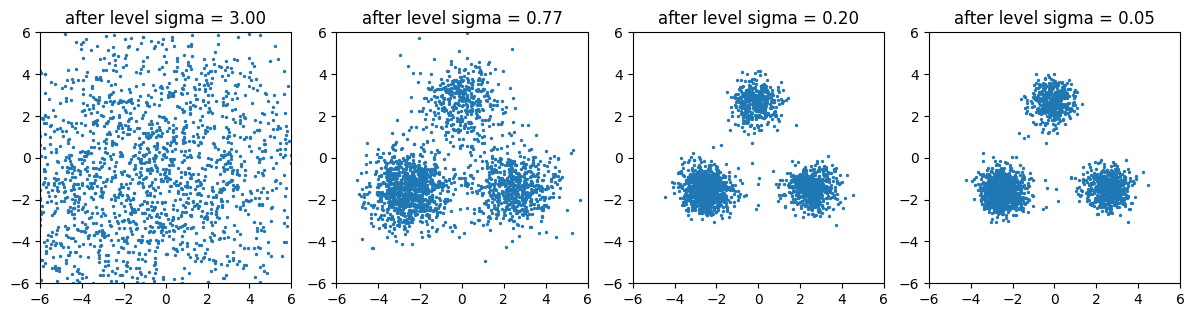

In [5]:
torch.manual_seed(3)
x, snapshots = x_init.clone(), []
for i in range(L):
    x = annealed_langevin(score, x, sigmas[i:i + 1])
    if i in (0, 3, 6, 9):
        snapshots.append((sigmas[i].item(), x.clone()))
fig, axes = d2l.plt.subplots(1, 4, figsize=(12, 3.3))
for ax, (sigma, pts) in zip(axes, snapshots):
    ax.scatter(pts[:, 0], pts[:, 1], s=2)
    ax.set_xlim(-6, 6), ax.set_ylim(-6, 6), ax.set_aspect('equal')
    ax.set_title(f'after level sigma = {sigma:.2f}')
fig.tight_layout()

@Song.Ermon.2020 describe this coarse-to-fine progression as an
iterative refining procedure. For images the same sequence appears as
a picture
that emerges from noise: typically the coarsest levels fix the global
layout and the finer ones add detail, so that each level only has to correct
what the previous one left unresolved.

## A Noise-Conditional Network for Images

### The U-Net

For images the score network must accept a $28 \times 28$ input, produce an
output of the same shape, and take the noise level as a further input. The
standard architecture is a U-Net [@Ronneberger.Fischer.Brox.2015],
adopted in a RefineNet variant for score models by
@song2019generative and for diffusion models by
@ho2020denoising. An encoder halves the resolution in stages while
widening the channels, a decoder reverses the process, and skip connections
copy each encoder stage's features to the decoder stage of the same
resolution, so that fine detail does not have to survive the bottleneck (a
fully convolutional encoder--decoder without such skip connections serves
segmentation in that section; the U-Net adds them). The noise level
enters through an embedding, as in @ho2020denoising: the level
index is mapped to sinusoidal features, as in the positional encodings of
that section, passed through a small multilayer
perceptron, and added to the features inside every block
(@song2019generative instead condition through a modified
conditional instance normalization). The class below is a small instance of this design, drawn
in the figure, with about 340 thousand parameters. Its
`cond` argument accepts an optional
extra embedding, which that section uses for class labels,
and its channel arguments let that section apply the same
network to one-hot token images; here both are left at their defaults. The
class is saved to the `d2l` library because the later sections use it
unchanged.

![The noise-prediction U-Net of this chapter. Two down-sampling stages, a bottleneck, and two up-sampling stages, with skip connections joining equal resolutions. The conditioning scalar $t$ (a noise level index here, a diffusion step later) is embedded and added inside every block.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-diffusion-unet.svg)

In [6]:
def sinusoidal_embedding(t, dim):
    """Map integer steps t (shape (n,)) to sinusoidal features (n, dim)."""
    freqs = torch.exp(-math.log(10000)  # on t's device, so the caller may use a GPU
                      * torch.arange(dim // 2, device=t.device) / (dim // 2))
    args = t.float()[:, None] * freqs[None]
    return torch.cat([torch.sin(args), torch.cos(args)], 1)

class ResBlock(nn.Module):
    """Two 3x3 convolutions with group normalization and an added embedding."""
    def __init__(self, c_in, c_out, emb_dim):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, c_in)
        self.conv1 = nn.Conv2d(c_in, c_out, 3, padding=1)
        self.emb = nn.Linear(emb_dim, c_out)
        self.norm2 = nn.GroupNorm(8, c_out)
        self.conv2 = nn.Conv2d(c_out, c_out, 3, padding=1)
        self.skip = nn.Conv2d(c_in, c_out, 1) if c_in != c_out else nn.Identity()

    def forward(self, x, emb):
        h = self.conv1(nn.functional.silu(self.norm1(x)))
        h = h + self.emb(emb)[:, :, None, None]
        h = self.conv2(nn.functional.silu(self.norm2(h)))
        return h + self.skip(x)

class UNet(nn.Module):
    """A small U-Net for 28x28 images, conditioned on a step index t."""
    def __init__(self, ch=32, emb_dim=128, in_channels=1, out_channels=1):
        super().__init__()
        self.emb_dim = emb_dim
        self.emb_mlp = nn.Sequential(nn.Linear(emb_dim, emb_dim), nn.SiLU(),
                                     nn.Linear(emb_dim, emb_dim))
        self.inc = nn.Conv2d(in_channels, ch, 3, padding=1)
        self.down1 = ResBlock(ch, ch, emb_dim)                    # 28 x 28
        self.pool1 = nn.Conv2d(ch, ch, 3, stride=2, padding=1)    # -> 14 x 14
        self.down2 = ResBlock(ch, 2 * ch, emb_dim)
        self.pool2 = nn.Conv2d(2 * ch, 2 * ch, 3, stride=2, padding=1)  # -> 7 x 7
        self.mid = ResBlock(2 * ch, 2 * ch, emb_dim)
        self.up1 = ResBlock(4 * ch, ch, emb_dim)                  # 14 x 14
        self.up0 = ResBlock(2 * ch, ch, emb_dim)                  # 28 x 28
        self.outc = nn.Sequential(nn.GroupNorm(8, ch), nn.SiLU(),
                                  nn.Conv2d(ch, out_channels, 3, padding=1))

    def forward(self, x, t, cond=None):
        emb = sinusoidal_embedding(t, self.emb_dim)
        if cond is not None:
            emb = emb + cond
        emb = self.emb_mlp(emb)
        h1 = self.down1(self.inc(x), emb)
        h2 = self.down2(self.pool1(h1), emb)
        h = self.mid(self.pool2(h2), emb)
        h = nn.functional.interpolate(h, scale_factor=2, mode='nearest')
        h = self.up1(torch.cat([h, h2], 1), emb)  # skip connection
        h = nn.functional.interpolate(h, scale_factor=2, mode='nearest')
        h = self.up0(torch.cat([h, h1], 1), emb)  # skip connection
        return self.outc(h)

### Training and Denoising at Several Levels

We train the U-Net as a noise-conditional score network on Fashion-MNIST,
with pixels scaled to $[-1, 1]$ and a ladder of ten levels from
$\sigma_1 = 2$, at which an image is buried in noise, to $\sigma_L = 0.02$.
The network is conditioned on the level index and outputs a noise
prediction $\boldsymbol{\epsilon}_{\boldsymbol{\theta}}$, the convention of
that section (so that
$\mathbf{f}_{\boldsymbol{\theta}} = -\boldsymbol{\epsilon}_{\boldsymbol{\theta}}$
in the notation above). The loss is the equation with
$\lambda(\sigma) = \sigma^2$, averaged over pixels, and the score at level
$i$ is $-\boldsymbol{\epsilon}_{\boldsymbol{\theta}} / \sigma_i$. Six
hundred updates take a few minutes
on a laptop processor; the published models train for hundreds of thousands.

In [7]:
fmnist = d2l.FashionMNIST(batch_size=128)
X = fmnist.train.data.float()[:, None] / 255 * 2 - 1
X_test = fmnist.val.data.float()[:, None] / 255 * 2 - 1
img_sigmas = torch.exp(torch.linspace(math.log(2.0), math.log(0.02), 10))

torch.manual_seed(4)
unet = UNet()
optimizer = torch.optim.Adam(unet.parameters(), lr=1e-3)
for step in range(600):
    x = X[torch.randint(0, len(X), (128,))]
    level = torch.randint(0, 10, (128,))
    eps = torch.randn_like(x)
    x_noisy = x + img_sigmas[level][:, None, None, None] * eps
    loss = 0.5 * ((unet(x_noisy, level) - eps) ** 2).mean()  # noise prediction
    optimizer.zero_grad(), loss.backward(), optimizer.step()
print(f'final training loss: {loss.item():.3f}')

final training loss: 0.115


One network now approximates the scores of Fashion-MNIST at ten noise
levels. The
cell checks this claim with Tweedie's formula the equation
at three of the levels: the same network, told the level, denoises test
images corrupted at $\sigma \approx 0.09$, $0.43$, and $2$. It reports the
per-pixel squared error before and after denoising and shows, for six
images, the clean originals and then the noisy input and the reconstruction
at each level, from fine to coarse.

sigma = 0.09: per-pixel squared error noisy 0.009, denoised 0.002


sigma = 0.43: per-pixel squared error noisy 0.186, denoised 0.022


sigma = 2.00: per-pixel squared error noisy 4.004, denoised 0.132


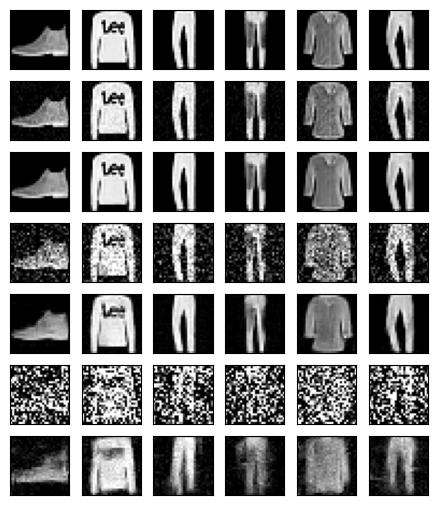

In [8]:
torch.manual_seed(5)
x = X_test[:500]
rows = []
for level in (6, 3, 0):  # sigma about 0.09, 0.43, 2
    sigma = img_sigmas[level]
    x_noisy = x + sigma * torch.randn_like(x)
    with torch.no_grad():
        x_hat = x_noisy - sigma * unet(x_noisy, torch.full((len(x),), level))
    print(f'sigma = {sigma:.2f}: per-pixel squared error noisy {((x_noisy - x) ** 2).mean():.3f}, '
          f'denoised {((x_hat - x) ** 2).mean():.3f}')
    rows += [x_noisy[:6], x_hat[:6]]
imgs = torch.cat([x[:6]] + rows).clamp(-1, 1) / 2 + 0.5
d2l.show_images(imgs.permute(0, 2, 3, 1).repeat(1, 1, 1, 3), 7, 6, scale=0.9);

At the fine level the reconstruction is close to the original. At
$\sigma \approx 0.43$ it is the smooth posterior mean seen in
that section. At $\sigma = 2$ the input is
indistinguishable from noise by eye, yet the reconstruction is a blurred
silhouette with the original's overall layout and none of its detail: the
posterior mean at such a level averages the many clean images consistent
with the noisy input, which share its coarse shape but not its fine
structure, and the network has learned what that average looks like. These
three
reconstructions are the ingredients of iterative refinement: the coarse
level supplies the layout, the intermediate level the shape, the fine level
the detail. Generating images from scratch with annealed Langevin dynamics
requires all ten scores to be accurate, and in particular the intermediate
ones on inputs that are not real noisy images but the chain's own states;
@song2019generative achieve this with training runs orders of
magnitude longer than the one above, and @Song.Ermon.2020 refine
the choice of ladder, step size, and steps per level. Exercise 6 runs the
sampler on this small network. that section reaches
recognizable samples within the chapter's budget with the closely related
sampler of the next section.

## Conditioning through Bayes' Rule

Score models offer a direct route to conditional generation. Suppose a
label $y$ is attached to each image, and a classifier $p(y \mid \mathbf{x})$
is available. Bayes' rule gives $p(\mathbf{x} \mid y) \propto p(\mathbf{x})\, p(y \mid \mathbf{x})$,
and because the score is a gradient in $\mathbf{x}$, the normalizer
$p(y)$ disappears:

$$
\nabla_{\mathbf{x}} \log p(\mathbf{x} \mid y)
= \nabla_{\mathbf{x}} \log p(\mathbf{x}) + \nabla_{\mathbf{x}} \log p(y \mid \mathbf{x}).
$$

The network above learned the unconditional score, and the second term is
the input gradient of a classifier. Adding the two and running a
score-based sampler, Langevin dynamics here or the diffusion samplers of
the later sections, draws from the class-conditional distribution with no
retraining of the score network [@song2021score; @Dhariwal.Nichol.2021],
up to the errors of the learned score, of the classifier, and of the finite
chain.
Because the
sampler operates at each noise level, the classifier must be evaluated on
noisy inputs at that level, which requires a classifier trained on noisy
data; that section trains one and runs this rule as
*classifier guidance*. The same identity underlies the guidance methods
used with diffusion
models, developed in that section and
applied in that section, where the second term is
replaced by the difference between a conditional and an unconditional
network.

Score-based generative models, as assembled so far, train stably by
regression and need no adversary and no normalizer. Their image samples
were reported as comparable to those of the adversarial models of the time
[@song2019generative], and, with improved training techniques, as
rivaling the best of them on several datasets [@Song.Ermon.2020]. Three
limitations remain. Sampling runs a Markov chain of hundreds or thousands of
network evaluations, the model provides no tractable likelihood, and the
noise ladder
is a sequence of separate distributions rather than a single process with a
beginning and an end. The diffusion formulation of the next section
addresses the last two, with a single process and a bound on the
likelihood; that section shortens the chain.

## Summary

A noise-conditional score network learns the scores of the Gaussian-perturbed
data at a ladder of noise levels with one set of parameters, trained on the
denoising objective at every level and weighted by $\sigma^2$ so that all
levels contribute terms of comparable size, which amounts to predicting the
added noise. Annealed Langevin dynamics runs the Langevin chain level by
level from the coarsest to the finest, with step sizes proportional to
$\sigma_i^2$; each level starts from a sample of the previous one, so the
chain is likely to start each level where the current score is well
estimated. The mode proportions are settled at the coarse levels, where the
chain mixes while the modes are still broad.

On the running example the annealed sampler recovered the mode weights to
within a few hundredths, with a slightly inflated spread and about two
percent strays, using a thousand network evaluations, whereas the same
budget spent at the finest level alone left the weights at their initial
values and nearly half of the chains far from every mode. A U-Net
conditioned on the level index learned approximations of the scores of
Fashion-MNIST at ten noise levels in a few minutes, good enough to denoise at
the three levels
tested, from the layout at the coarsest to the detail at the finest;
generating from noise is left to Exercise 6, and the original work trained
for orders of magnitude longer. Bayes' rule makes conditional sampling a
matter of adding a classifier gradient to the score.

## Exercises

1. **The weighting.** With the parameterization
   $\mathbf{s}_{\boldsymbol{\theta}}(\mathbf{x}, \sigma) = \mathbf{f}_{\boldsymbol{\theta}}(\mathbf{x}, \sigma) / \sigma$,
   show that the $\sigma^2$-weighted denoising objective
   the equation equals
   $\tfrac{1}{2L} \sum_i \mathbb{E}\|\mathbf{f}_{\boldsymbol{\theta}}(\mathbf{x} + \sigma_i \boldsymbol{\epsilon}, \sigma_i) + \boldsymbol{\epsilon}\|^2$.
   Then compute, for a single Gaussian data distribution
   $\mathcal{N}(0, s^2)$ in one dimension, the value of the unweighted
   objective at the optimum for each $\sigma_i$, and explain what an
   unweighted sum over a ladder from $\sigma = 3$ to $\sigma = 0.05$ would
   emphasize.
1. **Step sizes.** The step size in the equation
   is $\alpha_i = \epsilon\, \sigma_i^2 / \sigma_L^2$. For a single Gaussian
   target $p_{\sigma_i} = \mathcal{N}(0, s^2 + \sigma_i^2)$ with
   $s \ll \sigma_i$, show that one Langevin step contracts the distance to the
   mean by the factor $1 - \alpha_i / (2 (s^2 + \sigma_i^2)) \approx 1 - \epsilon / (2 \sigma_L^2)$,
   independent of the level. What does this say about the number of steps a
   level needs, and why is the injected noise $\sqrt{\alpha_i}$ nevertheless
   different at every level?
1. [code] **Exact scores through the ladder.** Replace the network in the
   annealed sampler by the exact score of $p_{\sigma_i}$, available from
   `GaussianMixture.score` with the `sigma` argument, and rerun the schedule
   with $20$ and $100$ steps per level, and the thousand-step run at the
   finest level alone. Compare with the learned-score results and decide
   which part of each discrepancy from the target is due to the finite chain
   and which to the learned scores.
1. [code] **The coarsest level.** Rerun the annealed sampler with the ladder
   truncated to start at the level nearest $0.5$ instead of $3$, keeping all other
   settings. Report the mode weights and explain the result using
   the figure.
1. [code] **A classifier gradient.** Label each training point of the running
   example by the component that generated it, train a small classifier on
   the *noisy* points at each level, and add its input gradient to the
   learned score as in the equation during annealed
   sampling. Verify that conditioning on each class produces samples from the
   corresponding component, and measure the fraction that lands in the wrong
   one.
1. [code] **Annealed Langevin on images.** Run annealed Langevin dynamics with
   the trained U-Net, starting from uniform noise on $[-1, 1]$, with $100$
   steps per level and the step-size ratio $\epsilon / \sigma_L^2 = 0.2$ of
   @song2019generative, whose $\epsilon = 2 \times 10^{-5}$ and
   $\sigma_L = 0.01$ refer to pixels in $[0, 1]$ (pass `scale=0.2` and the
   ladder `img_sigmas`). The sampler calls its score with noise levels,
   whereas the U-Net takes a level index and predicts the noise, so wrap it
   as the score `-unet(x, level) / sigma`, with `level` the index of the
   current level. Display the states after each level. Describe what the
   coarse levels establish and what the fine levels fail to add at this
   training budget. Then train for $3000$ steps instead of $600$ and repeat.